# 🧠 Iterative-RLHF: Multi-Dataset × Multi-Model RAFT Pipeline (v2 — Kaggle 2×T4)

> **Reward rAnked Fine-Tuning (RAFT)** — an iterative alignment technique where a policy model samples multiple candidate responses per prompt, a reward model selects the best one, and the policy is fine-tuned on those best-of-N selections. Repeated across iterations, this progressively aligns the policy without explicit PPO or REINFORCE.

---

## ✅ All Fixes Applied (v2 adds GPU + reward=0 fixes)

| # | Issue | Fix |
|---|-------|-----|
| 1 | `requires_grad` / gradient checkpoint warning | `use_reentrant=False` in `prepare_model_for_kbit_training` and `TrainingArguments` |
| 2 | `use_cache` incompatible with gradient checkpointing | `model.config.use_cache = False` set explicitly after model load |
| 3 | Reward collapses to 0.00 after iter 1 (LoRA double-stack) | `get_base_model()` unwraps all PeftModel layers before re-applying LoRA |
| 4 | Model state bleeds across datasets | `PolicyEngine` re-instantiated fresh per dataset inside the loop |
| 5 | Pad tokens inflate training loss | Labels masked with `-100` at all pad-token positions |
| 6 | LoRA misses attention layers on some architectures | `get_target_modules()` auto-detects per-model layer names |
| 7 | Reward model always returns 5.0 (Flan-T5 parse failure) | Replaced with **Qwen2.5-3B-Instruct** 4-bit LLM-as-Judge with 3-level parse fallback |
| 8 | No per-iteration detail storage | Full JSON saved per iteration: prompts, all candidates, scores, reasons, winner |
| 9 | No live visualization | `LivePlotter` redraws reward + loss dashboard after every iteration |
| 10 | numpy 2.2.x breaks scipy/sklearn import chain | numpy pinned to `<2.1.0` in Cell 1; kernel restart forced |
| 11 | **[v2] Reward=0 in iter 2+ (empty generation after LoRA wrap)** | **`use_cache=True` re-enabled after training; reward cache cleared between iterations** |
| 12 | **[v2] Both models fighting over GPU 0 (OOM/contention)** | **Policy pinned to `cuda:0`, Reward pinned to `cuda:1`** |
| 13 | **[v2] Kaggle 2×T4 not being used** | **`CUDA_VISIBLE_DEVICES=0,1`, bumped batch size, GPU memory logger per iteration** |

## ⏱️ Rough Time Estimation (Kaggle 2×T4, 3 models × 3 datasets × 3 iterations)

| Phase | Per iteration | Total |
|-------|--------------|-------|
| Sampling (4 candidates × 10 prompts) | ~3–5 min | — |
| Reward scoring (40 calls to Qwen-3B) | ~4–6 min | — |
| LoRA fine-tune (10 examples, 1 epoch) | ~2–3 min | — |
| **Per iteration total** | **~9–14 min** | — |
| Per model × dataset (3 iterations) | — | ~27–42 min |
| **Full run (3 models × 3 datasets)** | — | **~4–6 hours** |

> GPU memory layout: Policy model (Qwen-1.5B/Phi-2/TinyLlama, 4-bit ≈1–2GB) on GPU 0, Reward model (Qwen-3B, 4-bit ≈2GB) on GPU 1. Both T4s stay well under 16GB.

## Policy Models (open, no HF gate, no token)
| Model | Params | License |
|-------|--------|---------||
| `Qwen/Qwen2.5-1.5B-Instruct` | 1.5B | Apache-2.0 |
| `microsoft/phi-2` | 2.7B | MIT |
| `TinyLlama/TinyLlama-1.1B-Chat-v1.0` | 1.1B | Apache-2.0 |

## Reward Model (local LLM-as-Judge, no API key)
| Model | Params | License |
|-------|--------|---------||
| `Qwen/Qwen2.5-3B-Instruct` | 3B (4-bit ≈2GB) | Apache-2.0 |

## Architecture
```
GPU 0 (T4 16GB): Policy Model + LoRA Training
GPU 1 (T4 16GB): Reward Model (Qwen2.5-3B, inference-only)

For each Policy Model:
  For each Dataset:               ← model RESET here (fresh weights)
    For each Iteration 1 → 3:
      1. Sample N candidates per prompt     [GPU 0]
      2. Score with Qwen2.5-3B-Instruct     [GPU 1]
      3. Select best-of-N
      4. LoRA fine-tune on winners          [GPU 0, always from unwrapped base]
      5. Re-enable use_cache + clear reward cache
      6. Save detail JSON + flush CSV
      7. Redraw live reward & loss dashboard
```

---
## Cell 1 — Install Dependencies

**FIX #10:** numpy is pinned to `<2.1.0` before anything else installs it.  
numpy 2.2.x breaks `scipy → sklearn → transformers` import chain via a missing `_center` symbol.  
The cell ends with a hard kernel restart (`os.kill`) so the pinned version is picked up cleanly.

In [1]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# FIX #10: numpy pinned <2.1.0 to avoid scipy/_center import error
# ============================================================

# Step 1: Pin numpy FIRST before anything can upgrade it
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "numpy>=1.26.0,<2.1.0"])

# Step 2: Reinstall scipy against the pinned numpy
!pip install -q "scipy>=1.10.0,<1.17.0"

# Step 3: All other dependencies
!pip install -q -U \
    bitsandbytes \
    peft \
    accelerate \
    datasets \
    "transformers>=4.40.0" \
    sentencepiece \
    tqdm \
    "matplotlib>=3.5,<=3.10" \
    seaborn \
    ipywidgets \
    scikit-learn

print("✅ All dependencies installed.")
print("🔄 Restarting kernel to pick up pinned numpy...")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 110.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 107.1 MB/s eta 0:00:0000:01
✅ All dependencies installed.
🔄 Restarting kernel to pick up pinned numpy...


> ⚠️ **After the kernel restarts, run Cell 1 once more** (it will exit again — that is normal), then run from Cell 2 onwards. The second run confirms all packages are at the right versions.

---
## Cell 2 — Imports, Logging, GPU Setup & Project Configuration

**[v2] FIX #12 & #13:** `CUDA_VISIBLE_DEVICES=0,1` exposes both T4s. GPU memory is logged per iteration to confirm utilization.

In [2]:
# ============================================================
# CELL 2 — IMPORTS, LOGGING, GPU SETUP & PROJECT CONFIGURATION
# [v2] FIX #12 #13: Kaggle 2×T4 multi-GPU configuration
# ============================================================
import os
import gc
import json
import logging
import re
import random
import time
from datetime import datetime
from pathlib import Path
from typing import List, Dict, Optional, Tuple

# ── [v2] FIX #13: Expose both T4s BEFORE importing torch ────
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import clear_output, display
from tqdm.auto import tqdm

from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from peft import (
    LoraConfig,
    PeftModel,
    get_peft_model,
    prepare_model_for_kbit_training,
)

# ── Logging ──────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("IterativeRLHF")

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── [v2] FIX #12 #13: GPU verification ───────────────────────
if torch.cuda.is_available():
    N_GPU = torch.cuda.device_count()
    logger.info(f"✅ GPUs available: {N_GPU}")
    for i in range(N_GPU):
        props = torch.cuda.get_device_properties(i)
        logger.info(f"  GPU {i}: {props.name} — {props.total_memory / 1e9:.1f} GB")
    if N_GPU < 2:
        logger.warning("Only 1 GPU found — make sure Kaggle accelerator is set to 2×T4")
else:
    N_GPU = 0
    logger.warning("No CUDA GPUs found — running on CPU (will be very slow)")

# Primary device — policy model always on GPU 0
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def log_gpu_memory(label: str = "") -> None:
    """[v2] Log current GPU memory usage for both T4s."""
    if not torch.cuda.is_available():
        return
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        reserved = torch.cuda.memory_reserved(i) / 1e9
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        logger.info(
            f"  {'['+label+'] ' if label else ''}GPU {i}: "
            f"{alloc:.1f}GB alloc / {reserved:.1f}GB reserved / {total:.1f}GB total"
        )


# ── Policy Models — open, no HF gate, no token needed ─────────
POLICY_MODELS: List[str] = [
    "Qwen/Qwen2.5-1.5B-Instruct",           # Apache-2.0
    "microsoft/phi-2",                        # MIT, 2.7B
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",   # Apache-2.0, 1.1B
]

# ── Dataset Registry ──────────────────────────────────────────
DATASET_REGISTRY: List[Dict] = [
    {"name": "webglm", "hf_id": "vietgpt/webglm-qa",    "task": "rag_qa"},
    {"name": "yelp",   "hf_id": "yelp_review_full",      "task": "review"},
    {"name": "xsum",   "hf_id": "EdinburghNLP/xsum",     "task": "summarization"},
]

# ── Project Configuration ─────────────────────────────────────
PROJECT_CONFIG: Dict = {
    # Reward LLM — local, 4-bit, no API key
    "reward_model_id":        "Qwen/Qwen2.5-3B-Instruct",
    # Data
    "num_prompts":            30,
    # RAFT
    "iterations":             3,
    "num_samples_per_prompt": 5,
    # LoRA
    "lora_r":                 16,
    "lora_alpha":             16,   # FIX #16: match rank — alpha=2r doubles effective LR scaling
    "lora_dropout":           0.05,
    # Training — [v2] bumped batch size for 2×T4 32GB headroom
    "learning_rate":          2e-5,
    "max_seq_len":            256,  # FIX #16: fewer pad tokens → more real signal per step
    "train_batch_size":       4,    # was 2 — doubled for 2×T4
    "grad_accum_steps":       2,    # was 4 — halved since batch is larger
    # Generation
    "max_new_tokens":         256,
    "temperature":            0.7,
    # Output
    "output_root":            Path("./raft_outputs"),
}
PROJECT_CONFIG["output_root"].mkdir(parents=True, exist_ok=True)

logger.info("Project config:")
for k, v in PROJECT_CONFIG.items():
    logger.info(f"  {k:<28} = {v}")

print(f"\n🖥️  GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        mem = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"   GPU {i}: {torch.cuda.get_device_name(i)} — {mem:.1f} GB")

print(f"\n📦 Policy models  : {POLICY_MODELS}")
print(f"🏆 Reward model   : {PROJECT_CONFIG['reward_model_id']} (local 4-bit, no API key)")
print(f"📚 Datasets       : {[d['name'] for d in DATASET_REGISTRY]}")
print(f"🔢 numpy version  : {np.__version__}  (must be <2.1.0)")
print(f"\n[v2] GPU layout   : Policy → cuda:0 | Reward → cuda:1")

06:18:23 [INFO] IterativeRLHF — ✅ GPUs available: 2
06:18:24 [INFO] IterativeRLHF —   GPU 0: Tesla T4 — 15.6 GB
06:18:24 [INFO] IterativeRLHF —   GPU 1: Tesla T4 — 15.6 GB
06:18:24 [INFO] IterativeRLHF — Project config:
06:18:24 [INFO] IterativeRLHF —   reward_model_id              = Qwen/Qwen2.5-3B-Instruct
06:18:24 [INFO] IterativeRLHF —   num_prompts                  = 30
06:18:24 [INFO] IterativeRLHF —   iterations                   = 3
06:18:24 [INFO] IterativeRLHF —   num_samples_per_prompt       = 5
06:18:24 [INFO] IterativeRLHF —   lora_r                       = 16
06:18:24 [INFO] IterativeRLHF —   lora_alpha                   = 16
06:18:24 [INFO] IterativeRLHF —   lora_dropout                 = 0.05
06:18:24 [INFO] IterativeRLHF —   learning_rate                = 2e-05
06:18:24 [INFO] IterativeRLHF —   max_seq_len                  = 256
06:18:24 [INFO] IterativeRLHF —   train_batch_size             = 4
06:18:24 [INFO] IterativeRLHF —   grad_accum_steps             = 2
06:18:24


🖥️  GPU available: True
   GPU 0: Tesla T4 — 15.6 GB
   GPU 1: Tesla T4 — 15.6 GB

📦 Policy models  : ['Qwen/Qwen2.5-1.5B-Instruct', 'microsoft/phi-2', 'TinyLlama/TinyLlama-1.1B-Chat-v1.0']
🏆 Reward model   : Qwen/Qwen2.5-3B-Instruct (local 4-bit, no API key)
📚 Datasets       : ['webglm', 'yelp', 'xsum']
🔢 numpy version  : 2.0.2  (must be <2.1.0)

[v2] GPU layout   : Policy → cuda:0 | Reward → cuda:1


---
## Cell 3 — DatasetHub: Multi-Dataset Loading & Preprocessing

In [3]:
# ============================================================
# CELL 3 — DATASET HUB
# ============================================================

STAR_LABELS = {0: "1-star", 1: "2-star", 2: "3-star", 3: "4-star", 4: "5-star"}


def load_webglm_data(num_prompts: int) -> Tuple[List[str], List[str]]:
    """
    Load vietgpt/webglm-qa.
    Schema: 'messages' list of {role, content}.
    User turn: 'References:\n\n[1]...\n\nQuestion: <question>'
    """
    logger.info(f"[WebGLM] Streaming {num_prompts} examples…")
    ds = load_dataset("vietgpt/webglm-qa", split="train",
                      streaming=True).take(num_prompts)
    prompts, contexts = [], []
    for example in ds:
        messages = example["messages"]
        user_content = next(
            (m["content"] for m in messages if m["role"] == "user"), ""
        )
        if "Question:" in user_content:
            parts    = user_content.split("Question:", maxsplit=1)
            context  = parts[0].strip()
            question = parts[1].strip()
        else:
            question = user_content.strip()
            context  = ""
        if question:
            prompts.append(question)
            contexts.append(context)
    logger.info(f"[WebGLM] Loaded {len(prompts)} pairs.")
    return prompts, contexts


def load_yelp_data(num_prompts: int) -> Tuple[List[str], List[str]]:
    """
    Load yelp_review_full.
    Schema: 'text' (review), 'label' (0–4 → 1–5 stars).
    """
    logger.info(f"[Yelp] Streaming {num_prompts} examples…")
    ds = load_dataset("yelp_review_full", split="train",
                      streaming=True).take(num_prompts * 3)
    prompts, contexts = [], []
    seen = 0
    for example in ds:
        if seen >= num_prompts:
            break
        text     = example["text"].strip()
        label    = example["label"]
        star_str = STAR_LABELS.get(label, "3-star")
        sentences = [s.strip() for s in text.split(".") if s.strip()]
        seed = sentences[0] + "." if sentences else ""
        prompt  = (
            f"Write a {star_str} Yelp restaurant review that starts with: \"{seed}\" "
            f"Continue the review naturally in 3-5 sentences."
        )
        context = f"Target sentiment: {star_str}. Opening sentence: {seed}"
        prompts.append(prompt)
        contexts.append(context)
        seen += 1
    logger.info(f"[Yelp] Loaded {len(prompts)} pairs.")
    return prompts, contexts


def load_xsum_data(num_prompts: int) -> Tuple[List[str], List[str]]:
    """
    Load EdinburghNLP/xsum.
    Schema: 'document' (BBC article), 'summary' (one-sentence gold).
    """
    logger.info(f"[XSum] Streaming {num_prompts} examples…")
    ds = load_dataset("EdinburghNLP/xsum", split="train",
                      streaming=True).take(num_prompts)
    prompts, contexts = [], []
    for example in ds:
        doc     = example["document"].strip()
        context = doc[:1500]
        prompt  = "Summarise the following BBC news article in exactly ONE concise sentence:"
        prompts.append(prompt)
        contexts.append(context)
    logger.info(f"[XSum] Loaded {len(prompts)} pairs.")
    return prompts, contexts


_LOADERS = {
    "webglm": load_webglm_data,
    "yelp":   load_yelp_data,
    "xsum":   load_xsum_data,
}


def load_dataset_by_name(name: str,
                         num_prompts: int) -> Tuple[List[str], List[str]]:
    if name not in _LOADERS:
        raise ValueError(f"Unknown dataset '{name}'. Choose from: {list(_LOADERS)}")
    return _LOADERS[name](num_prompts)


# ── Preview ───────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  📚 DATASET PREVIEW")
print("═" * 60)

dataset_cache: Dict[str, Tuple[List[str], List[str]]] = {}
for ds_info in DATASET_REGISTRY:
    ds_name = ds_info["name"]
    p, c = load_dataset_by_name(ds_name, PROJECT_CONFIG["num_prompts"])
    dataset_cache[ds_name] = (p, c)
    print(f"\n▶ [{ds_name.upper()}]  {len(p)} examples")
    print(f"  Prompt  : {p[0][:120]}…")
    print(f"  Context : {c[0][:150]}…")

print("\n✅ All datasets loaded and cached.")

06:18:24 [INFO] IterativeRLHF — [WebGLM] Streaming 30 examples…
06:18:24 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/vietgpt/webglm-qa/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"



════════════════════════════════════════════════════════════
  📚 DATASET PREVIEW
════════════════════════════════════════════════════════════


06:18:24 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/vietgpt/webglm-qa/861de994099a712931fa67db2d8df3a73b4345af/README.md "HTTP/1.1 200 OK"
06:18:24 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/vietgpt/webglm-qa/861de994099a712931fa67db2d8df3a73b4345af/README.md "HTTP/1.1 200 OK"


README.md:   0%|          | 0.00/516 [00:00<?, ?B/s]

06:18:24 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/vietgpt/webglm-qa/resolve/861de994099a712931fa67db2d8df3a73b4345af/webglm-qa.py "HTTP/1.1 404 Not Found"
06:18:24 [INFO] httpx — HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/vietgpt/webglm-qa/vietgpt/webglm-qa.py "HTTP/1.1 404 Not Found"
06:18:24 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/datasets/vietgpt/webglm-qa/revision/861de994099a712931fa67db2d8df3a73b4345af "HTTP/1.1 200 OK"
06:18:24 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/vietgpt/webglm-qa/resolve/861de994099a712931fa67db2d8df3a73b4345af/.huggingface.yaml "HTTP/1.1 404 Not Found"
06:18:24 [INFO] httpx — HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=vietgpt/webglm-qa "HTTP/1.1 200 OK"
06:18:24 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/datasets/vietgpt/webglm-qa/tree/861de994099a712931fa67db2d8df3a73b4345af/data?recursive=true&expan

...

06:18:25 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/yelp_review_full/resolve/c1f9ee939b7d05667af864ee1cb066393154bf85/yelp_review_full.py "HTTP/1.1 307 Temporary Redirect"
06:18:25 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/Yelp/yelp_review_full/resolve/c1f9ee939b7d05667af864ee1cb066393154bf85/yelp_review_full.py "HTTP/1.1 404 Not Found"
06:18:25 [WARNING] huggingface_hub.utils._http — Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
06:18:25 [INFO] httpx — HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/yelp_review_full/yelp_review_full.py "HTTP/1.1 404 Not Found"
06:18:25 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/datasets/yelp_review_full/revision/c1f9ee939b7d05667af864ee1cb066393154bf85 "HTTP/1.1 307 Temporary Redirect"
06:18:25 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/dataset


▶ [YELP]  30 examples
  Prompt  : Write a 5-star Yelp restaurant review that starts with: "dr." Continue the review naturally in 3-5 sentences.…
  Context : Target sentiment: 5-star. Opening sentence: dr.…


README.md: 0.00B [00:00, ?B/s]

06:18:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/EdinburghNLP/xsum/resolve/7d4d486c2f8ef850b1a11aead99b894ff3dd7da9/xsum.py "HTTP/1.1 404 Not Found"
06:18:27 [INFO] httpx — HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/EdinburghNLP/xsum/EdinburghNLP/xsum.py "HTTP/1.1 404 Not Found"
06:18:27 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/datasets/EdinburghNLP/xsum/revision/7d4d486c2f8ef850b1a11aead99b894ff3dd7da9 "HTTP/1.1 200 OK"
06:18:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/EdinburghNLP/xsum/resolve/7d4d486c2f8ef850b1a11aead99b894ff3dd7da9/.huggingface.yaml "HTTP/1.1 404 Not Found"
06:18:27 [INFO] httpx — HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=EdinburghNLP/xsum "HTTP/1.1 200 OK"
06:18:27 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/datasets/EdinburghNLP/xsum/tree/7d4d486c2f8ef850b1a11aead99b894ff3dd7da9/data?recursive=true&expand=fal


▶ [XSUM]  30 examples
  Prompt  : Summarise the following BBC news article in exactly ONE concise sentence:…
  Context : The full cost of damage in Newton Stewart, one of the areas worst affected, is still being assessed.
Repair work is ongoing in Hawick and many roads i…

✅ All datasets loaded and cached.


---
## Cell 4 — PolicyEngine: Local LLM Wrapper

**Fixes in this cell:**
- **FIX #1** `use_reentrant=False` in `prepare_model_for_kbit_training` → silences `requires_grad` warning
- **FIX #2** `model.config.use_cache = False` set explicitly → silences `use_cache` incompatibility warning
- **FIX #3** `get_base_model()` loops through all PeftModel wrappers → prevents LoRA double-stacking
- **FIX #6** `get_target_modules()` auto-detects attention layer names per architecture
- **[v2] FIX #12** Policy model pinned to `cuda:0` explicitly

In [4]:
# ============================================================
# CELL 4 — POLICY ENGINE
# [v2] FIX #12: Policy model pinned to cuda:0
# ============================================================

TASK_SYSTEM_PROMPTS: Dict[str, str] = {
    "rag_qa": (
        "You are a helpful assistant. Use ONLY the provided context to answer "
        "the question. Be concise and factual."
    ),
    "review": (
        "You are a skilled Yelp reviewer. Write reviews that are vivid, "
        "natural, and accurately reflect the requested star rating."
    ),
    "summarization": (
        "You are an expert BBC news editor. Produce a single, fluent, "
        "abstractive sentence that captures the key point of the article."
    ),
}


def get_target_modules(model) -> List[str]:
    """
    FIX #6: Detect LoRA target modules by inspecting actual module names.
    Handles Qwen/Phi/TinyLlama (q_proj/v_proj), StableLM (query_key_value),
    and GPT-2 style (c_attn).
    """
    names = {n.split(".")[-1] for n, _ in model.named_modules()}
    if "query_key_value" in names:
        return ["query_key_value"]
    if "q_proj" in names and "v_proj" in names:
        return ["q_proj", "v_proj"]
    if "c_attn" in names:
        return ["c_attn"]
    logger.warning("Could not detect attention modules — defaulting to q_proj, v_proj")
    return ["q_proj", "v_proj"]


class PolicyEngine:
    """
    Wraps a HuggingFace causal-LM as the RAFT policy model.
    Loads in 4-bit NF4 quantization on cuda:0.
    [v2] Pinned to cuda:0 so Reward model can occupy cuda:1 without contention.
    """

    def __init__(self, model_id: str):
        self.model_id   = model_id
        self.model_name = model_id.split("/")[-1]

        logger.info(f"Loading tokenizer: {model_id}")
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_id, trust_remote_code=True
        )
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.tokenizer.padding_side = "left"

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
        )
        logger.info(f"Loading {self.model_name} in 4-bit NF4 on cuda:0…")
        raw_model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map="cuda:0",          # [v2] FIX #12: pin to GPU 0
            torch_dtype=torch.float16,
            trust_remote_code=True,
        )
        # FIX #1: use_reentrant=False suppresses requires_grad warning
        self._base_model = prepare_model_for_kbit_training(
            raw_model,
            use_gradient_checkpointing=True,
            gradient_checkpointing_kwargs={"use_reentrant": False},
        )
        # FIX #2: disable KV-cache to suppress use_cache warning during training
        self._base_model.config.use_cache = False
        self.model = self._base_model
        logger.info(f"✅ PolicyEngine ready: {self.model_name} on cuda:0")
        log_gpu_memory("after policy load")

    def _build_prompt(
        self,
        question: str,
        context: Optional[str],
        task: str = "rag_qa",
    ) -> str:
        sys_prompt = TASK_SYSTEM_PROMPTS.get(task, TASK_SYSTEM_PROMPTS["rag_qa"])
        if task == "rag_qa":
            ctx_block = f"\n\nContext:\n{context}" if context else ""
            return f"{sys_prompt}{ctx_block}\n\nQuestion: {question}\n\nAnswer:"
        elif task == "review":
            return f"{sys_prompt}\n\nContext: {context}\n\nTask: {question}\n\nReview:"
        elif task == "summarization":
            return f"{sys_prompt}\n\nArticle:\n{context}\n\n{question}\n\nSummary:"
        return f"{question}\n\n{context}\n\nResponse:"

    def generate(
        self,
        prompt: str,
        context: Optional[str] = None,
        task: str = "rag_qa",
        max_new_tokens: int = 256,
        temperature: float = 0.7,
    ) -> str:
        full_prompt = self._build_prompt(prompt, context, task)
        inputs = self.tokenizer(
            full_prompt, return_tensors="pt", truncation=True, max_length=1024
        ).to(self.model.device)
        with torch.no_grad():
            output_ids = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=temperature > 0,
                pad_token_id=self.tokenizer.pad_token_id,
                repetition_penalty=1.3,   # FIX #16: prevent repetition loops after LoRA fine-tuning
            )
        new_tokens = output_ids[0][inputs.input_ids.shape[1]:]
        return self.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    def sample_responses(
        self,
        prompt: str,
        context: Optional[str] = None,
        task: str = "rag_qa",
        num_samples: int = 4,
        **kwargs,
    ) -> List[str]:
        return [
            self.generate(prompt, context, task, **kwargs)
            for _ in range(num_samples)
        ]

    def get_base_model(self):
        """
        FIX #3 (v3): Unwrap all PeftModel layers using .unload() which
        properly removes LoRA weights instead of just traversing the wrapper.
        """
        m = self.model
        while isinstance(m, PeftModel):
            m = m.unload()
        return m

    def free_memory(self):
        del self.model
        del self._base_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        logger.info(f"♻️  GPU memory freed: {self.model_name}")


print("✅ PolicyEngine defined (fixed: grad-checkpoint, use_cache, get_base_model, target_modules, cuda:0 pin).")

✅ PolicyEngine defined (fixed: grad-checkpoint, use_cache, get_base_model, target_modules, cuda:0 pin).


---
## Cell 5 — LLM Reward Model (Qwen2.5-3B-Instruct, 4-bit)

**FIX #7:** Replaced Flan-T5-Large with Qwen2.5-3B-Instruct in 4-bit NF4.  
**[v2] FIX #12:** Reward model pinned to `cuda:1` — eliminates VRAM contention with policy on `cuda:0`.  
**[v2] FIX #11:** Empty-generation detection added; cache cleared between iterations from Cell 8.

In [5]:
# ============================================================
# CELL 5 — LLM REWARD MODEL (Qwen2.5-3B-Instruct, 4-bit NF4)
# FIX #7: Replaces Flan-T5 which always returned 5.0
# [v2] FIX #12: Pinned to cuda:1 — dedicated GPU, no contention with policy
# [v2] FIX #11: Empty-generation logging for reward=0 debugging
# Apache-2.0, no HF gate, no API key, ~2GB VRAM in 4-bit
# ============================================================

REWARD_PROMPT_TEMPLATES: Dict[str, str] = {
    "rag_qa": """You are a strict evaluator. Score this RAG response from 0 to 10.

Criteria:
- Grounding (0-4): Every claim must be supported by the context.
- Completeness (0-3): The question must be fully answered.
- Conciseness (0-3): No hallucination, padding, or repetition.

Context: {context}
Question: {question}
Response: {response}

You MUST respond in EXACTLY this format and nothing else:
Score: <integer 0-10>
Reason: <one sentence>""",

    "review": """You are a strict evaluator. Score this Yelp review from 0 to 10.

Criteria:
- Sentiment accuracy (0-4): Tone must match the requested star rating.
- Fluency (0-3): Text must be grammatically natural.
- Naturalness (0-3): Must sound like a genuine human review.

Context: {context}
Task: {question}
Response: {response}

You MUST respond in EXACTLY this format and nothing else:
Score: <integer 0-10>
Reason: <one sentence>""",

    "summarization": """You are a strict evaluator. Score this news summary from 0 to 10.

Criteria:
- Factual fidelity (0-4): All facts must be supported by the article.
- Abstractiveness (0-3): Must paraphrase, not copy verbatim.
- Readability (0-3): Must be a clean, grammatical single sentence.

Article excerpt: {context}
Task: {question}
Response: {response}

You MUST respond in EXACTLY this format and nothing else:
Score: <integer 0-10>
Reason: <one sentence>""",
}

# Few-shot anchor: shows the model the exact output format before it generates
FEW_SHOT_ANCHOR = """
Example of correct output format:
Score: 7
Reason: The response addresses the question well but includes one unsupported claim.

Now evaluate the following:
"""


class HFRewardModel:
    """
    LLM-as-Judge reward model using Qwen2.5-3B-Instruct in 4-bit NF4.

    [v2] Pinned to cuda:1 — dedicated GPU, no contention with policy on cuda:0.
    Greedy decoding ensures deterministic, reproducible scores.
    3-level parse fallback handles malformed outputs gracefully.
    """

    MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

    def __init__(self):
        # Determine reward device: cuda:1 if available, else cuda:0, else cpu
        if torch.cuda.is_available() and torch.cuda.device_count() >= 2:
            self.reward_device = "cuda:1"
            logger.info("[v2] Reward model → cuda:1 (dedicated GPU, no contention)")
        elif torch.cuda.is_available():
            self.reward_device = "cuda:0"
            logger.warning("Only 1 GPU found — reward model sharing cuda:0 with policy")
        else:
            self.reward_device = "cpu"

        logger.info(f"Loading LLM reward model: {self.MODEL_ID} on {self.reward_device}")

        self.tokenizer = AutoTokenizer.from_pretrained(
            self.MODEL_ID, trust_remote_code=True
        )
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        self.tokenizer.padding_side = "left"

        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
        )
        self.model = AutoModelForCausalLM.from_pretrained(
            self.MODEL_ID,
            quantization_config=bnb_config,
            device_map=self.reward_device,   # [v2] FIX #12: dedicated GPU
            torch_dtype=torch.float16,
            trust_remote_code=True,
        )
        self.model.eval()
        # Reward model is inference-only — KV-cache is fine and speeds up scoring
        self.model.config.use_cache = True
        self._cache: Dict[str, Tuple[float, str]] = {}
        logger.info(f"✅ LLM RewardModel ready: {self.MODEL_ID} on {self.reward_device}")
        log_gpu_memory("after reward load")

    def _build_prompt(
        self,
        question: str,
        context: str,
        response: str,
        task: str,
    ) -> str:
        """Build rubric prompt, inject few-shot anchor before the closing instruction."""
        template = REWARD_PROMPT_TEMPLATES.get(
            task, REWARD_PROMPT_TEMPLATES["rag_qa"]
        )
        rubric = template.format(
            context=context[:600],
            question=question[:200],
            response=response[:500],
        )
        parts = rubric.rsplit("You MUST respond", 1)
        if len(parts) == 2:
            return parts[0] + FEW_SHOT_ANCHOR + "You MUST respond" + parts[1]
        return rubric + FEW_SHOT_ANCHOR

    def _parse_score(self, text: str) -> Tuple[float, str]:
        """
        3-level fallback cascade:
          Level 1 — Exact match:   'Score: N'
          Level 2 — Any integer:   first integer 0-10 found anywhere in output
          Level 3 — Default 5.0:   logged as warning so frequency is visible
        [v2] FIX #11: empty output logged as ERROR for diagnosis
        """
        # [v2] FIX #11: detect empty reward model output early
        if not text.strip():
            logger.error(
                "Reward model returned EMPTY output — "
                "likely use_cache issue or OOM on reward GPU. Defaulting to 5.0."
            )
            return 5.0, "empty_output"

        # Level 1
        m_score  = re.search(r"Score:\s*(\d+(?:\.\d+)?)", text, re.IGNORECASE)
        m_reason = re.search(r"Reason:\s*(.+)",           text, re.IGNORECASE)
        if m_score:
            score  = max(0.0, min(10.0, float(m_score.group(1))))
            reason = m_reason.group(1).strip() if m_reason else text.strip()[:100]
            return score, reason

        # Level 2
        m_any = re.findall(r"\b(\d{1,2})\b", text)
        if m_any:
            valid = [int(x) for x in m_any if 0 <= int(x) <= 10]
            if valid:
                return float(valid[0]), f"(fallback-int) {text.strip()[:80]}"

        # Level 3
        logger.warning(
            f"Score parse failed — raw output: '{text.strip()[:120]}' — using 5.0"
        )
        return 5.0, "parse_failed"

    def score(
        self,
        question: str,
        context: str,
        response: str,
        task: str = "rag_qa",
    ) -> Tuple[float, str]:
        # [v2] FIX #11: log near-empty policy responses for diagnosis
        if not response or len(response.strip()) < 5:
            logger.warning(
                f"Policy returned near-empty response: '{response!r}' "
                f"— this causes reward=0.0. Check use_cache after training."
            )
            return 0.0, "Empty or trivially short response."

        cache_key = f"{task}:{hash(question + response)}"
        if cache_key in self._cache:
            return self._cache[cache_key]

        prompt = self._build_prompt(question, context, response, task)

        try:
            messages   = [{"role": "user", "content": prompt}]
            formatted  = self.tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
        except Exception:
            formatted = prompt

        inputs = self.tokenizer(
            formatted,
            return_tensors="pt",
            truncation=True,
            max_length=1536,
        ).to(self.model.device)

        with torch.no_grad():
            out = self.model.generate(
                **inputs,
                max_new_tokens=48,   # Score + Reason < 48 tokens
                do_sample=False,     # greedy = deterministic scoring
                temperature=1.0,
                pad_token_id=self.tokenizer.pad_token_id,
            )

        new_tokens = out[0][inputs["input_ids"].shape[1]:]
        text       = self.tokenizer.decode(
            new_tokens, skip_special_tokens=True
        ).strip()

        score, reason = self._parse_score(text)
        self._cache[cache_key] = (score, reason)
        return score, reason

    def select_best(
        self,
        prompts: List[str],
        contexts: List[str],
        all_candidates: List[List[str]],
        task: str = "rag_qa",
        verbose: bool = True,
    ) -> Tuple[List[str], List[float], List[List[Dict]]]:
        """
        Score all candidates and return:
          best_responses : winning response per prompt
          best_scores    : score of winning response
          all_scored     : full score details for every candidate (for JSON log)
        """
        best_responses, best_scores, all_scored = [], [], []

        for q, ctx, candidates in tqdm(
            zip(prompts, contexts, all_candidates),
            total=len(prompts),
            desc=f"🏆 Scoring [{task}]",
            leave=False,
        ):
            scored_candidates = []
            scores = []
            for cand in candidates:
                s, reason = self.score(q, ctx, cand, task=task)
                scores.append(s)
                scored_candidates.append({
                    "response": cand,
                    "score":    s,
                    "reason":   reason,
                })
            best_idx = int(np.argmax(scores))
            best_responses.append(candidates[best_idx])
            best_scores.append(scores[best_idx])
            all_scored.append(scored_candidates)

            if verbose:
                logger.info(
                    f"  [{task}] Best={scores[best_idx]:.1f} "
                    f"avg={np.mean(scores):.1f} "
                    f"min={np.min(scores):.1f} "
                    f"max={np.max(scores):.1f}"
                )

        return best_responses, best_scores, all_scored

    def free_memory(self):
        del self.model
        del self.tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        logger.info("♻️  Reward model GPU memory freed.")


print("✅ HFRewardModel defined (Qwen2.5-3B-Instruct, 4-bit NF4, cuda:1, 3-level parse fallback).")

✅ HFRewardModel defined (Qwen2.5-3B-Instruct, 4-bit NF4, cuda:1, 3-level parse fallback).


---
## Cell 6 — RAFT Fine-Tuning Step

**Fixes in this cell:**
- **FIX #3** Always calls `get_base_model()` — never applies LoRA to an existing PeftModel
- **FIX #5** Labels masked with `-100` at pad positions — loss ignores padding
- **FIX #6** `get_target_modules()` used for architecture-aware LoRA targeting
- **FIX #1** `gradient_checkpointing_kwargs={"use_reentrant": False}` in TrainingArguments
- **[v2] FIX #13** `train_batch_size=4`, `ddp_find_unused_parameters=False` for 2×T4

In [6]:
# ============================================================
# CELL 6 — RAFT FINE-TUNING STEP
# [v2] FIX #13: batch_size=4, ddp_find_unused_parameters=False for 2×T4
# ============================================================

def train_raft_step(
    policy_engine: "PolicyEngine",
    training_data: List[Dict],
    output_dir: Path,
    config: Dict,
    task: str = "rag_qa",
) -> Tuple["PeftModel", float]:
    """
    One RAFT step: LoRA fine-tune the policy on reward-selected pairs.

    FIX #3: Always applies LoRA to the unwrapped base model via
    get_base_model() — prevents double-stacking on iteration 2+.
    FIX #5: Pad token positions in labels set to -100.
    FIX #6: target_modules auto-detected per architecture.
    FIX #1: gradient_checkpointing_kwargs use_reentrant=False.
    [v2] FIX #13: ddp_find_unused_parameters=False for multi-GPU Trainer.
    """
    logger.info(f"[{task}] Fine-tuning {len(training_data)} examples → {output_dir}")
    output_dir.mkdir(parents=True, exist_ok=True)

    # FIX #3 (v3): Fully unwrap — call unload() if PeftModel, then get base
    from peft import PeftModel

    base_model = policy_engine.get_base_model()

    # Extra safety: if the model is still a PeftModel after unwrapping, unload it
    if isinstance(policy_engine.model, PeftModel):
        logger.info("  Unloading existing LoRA adapter before re-applying...")
        base_model = policy_engine.model.unload()
        policy_engine.model = base_model
        policy_engine._base_model = base_model

    # Re-disable use_cache before training
    base_model.config.use_cache = False

    # FIX #6: auto-detect target modules
    target_mods = get_target_modules(base_model)
    logger.info(f"  LoRA target modules: {target_mods}")

    lora_config = LoraConfig(
        r=config["lora_r"],
        lora_alpha=config["lora_alpha"],
        target_modules=target_mods,
        lora_dropout=config["lora_dropout"],
        bias="none",
        task_type="CAUSAL_LM",
    )
    peft_model = get_peft_model(base_model, lora_config)
    # FIX #2: re-disable use_cache after wrapping (LoRA wrap resets config)
    peft_model.config.use_cache = False
    peft_model.print_trainable_parameters()

    pad_id = policy_engine.tokenizer.pad_token_id

    def format_example(example: Dict) -> Dict:
        if task == "rag_qa":
            text = (
                f"Context:\n{example['context']}\n\n"
                f"Question: {example['prompt']}\n\n"
                f"Answer: {example['response']}"
            )
        elif task == "review":
            text = (
                f"Context: {example['context']}\n\n"
                f"Task: {example['prompt']}\n\n"
                f"Review: {example['response']}"
            )
        elif task == "summarization":
            text = (
                f"Article:\n{example['context']}\n\n"
                f"{example['prompt']}\n\n"
                f"Summary: {example['response']}"
            )
        else:
            text = (
                f"{example['context']}\n\n"
                f"{example['prompt']}\n\n"
                f"{example['response']}"
            )

        tokenized = policy_engine.tokenizer(
            text,
            truncation=True,
            max_length=config["max_seq_len"],
            padding="max_length",
        )
        # FIX #5: mask padding positions so loss ignores them
        tokenized["labels"] = [
            -100 if tok == pad_id else tok
            for tok in tokenized["input_ids"]
        ]
        return tokenized

    hf_dataset = Dataset.from_list(training_data).map(
        format_example,
        remove_columns=["prompt", "context", "response"],
    )

    # FIX #14 (v3): Bypass HuggingFace Trainer entirely with a plain PyTorch
    # training loop. Trainer + Accelerate wraps with DataParallel when it sees
    # 2 GPUs, and 4-bit bitsandbytes models cannot be replicated across devices.
    # A raw loop runs only on cuda:0 where the model lives — no wrapping at all.
    from torch.utils.data import DataLoader
    from torch.optim import AdamW
    from transformers import get_cosine_schedule_with_warmup
    from bitsandbytes.optim import PagedAdamW8bit

    device = torch.device("cuda:0")
    peft_model.train()

    collator = DataCollatorForLanguageModeling(policy_engine.tokenizer, mlm=False)
    dataloader = DataLoader(
        hf_dataset,
        batch_size=config["train_batch_size"],
        shuffle=True,
        collate_fn=collator,
        num_workers=0,
        pin_memory=False,
    )

    optimizer = PagedAdamW8bit(
        [p for p in peft_model.parameters() if p.requires_grad],
        lr=config["learning_rate"],
    )
    total_steps = len(dataloader)
    warmup_steps = max(1, int(0.05 * total_steps))
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    scaler = torch.cuda.amp.GradScaler()
    accum_steps = config["grad_accum_steps"]
    total_loss = 0.0
    num_batches = 0
    optimizer.zero_grad()

    logger.info(f"  [FIX #14 v3] Plain PyTorch loop on cuda:0 — {total_steps} steps, accum={accum_steps}")

    for step, batch in enumerate(dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.cuda.amp.autocast(dtype=torch.float16):
            outputs = peft_model(**batch)
            loss = outputs.loss / accum_steps

        scaler.scale(loss).backward()
        total_loss += loss.item() * accum_steps
        num_batches += 1

        if (step + 1) % accum_steps == 0 or (step + 1) == total_steps:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(peft_model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

    training_loss = total_loss / num_batches if num_batches > 0 else float("nan")
    logger.info(f"[{task}] Training loss: {training_loss:.4f}")

    # FIX #15: Release all training-loop state from GPU 0 immediately.
    # Without this, optimizer, scaler, gradients, and dataloader buffers
    # stay reserved on cuda:0, leaving ~7GB stranded and causing OOM /
    # empty-generation → reward=0 in iteration 2+.
    del optimizer, scheduler, scaler, dataloader
    for p in peft_model.parameters():
        p.grad = None
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize("cuda:0")
    logger.info(f"  [FIX #15] GPU 0 after cleanup: "
                f"{torch.cuda.memory_allocated(0)/1e9:.1f}GB alloc / "
                f"{torch.cuda.memory_reserved(0)/1e9:.1f}GB reserved")

    peft_model.save_pretrained(str(output_dir))
    logger.info(f"  LoRA adapter saved → {output_dir}")

    return peft_model, training_loss


print("✅ train_raft_step defined (fixed: label masking, target_modules, LoRA unwrap, grad-ckpt, 2×T4 args).")

✅ train_raft_step defined (fixed: label masking, target_modules, LoRA unwrap, grad-ckpt, 2×T4 args).


---
## Cell 7 — EvaluationTracker + LivePlotter

**FIX #8 — Per-iteration JSON storage:** Every iteration writes a full JSON with prompts, all candidate responses, individual scores + reasons, winner, and training loss.

**FIX #9 — Live visualization:** `LivePlotter` redraws a 2-row dashboard after every iteration.

In [7]:
# ============================================================
# CELL 7 — EVALUATION TRACKER + LIVE PLOTTER
# FIX #8: per-iteration JSON + CSV flush
# FIX #9: live dashboard redrawn after every iteration
# ============================================================

class EvaluationTracker:
    """
    Records per-(model × dataset × iteration) reward statistics.
    Saves a detailed JSON per iteration and flushes CSV after every log.
    """

    def __init__(self, output_root: Path):
        self.output_root = output_root
        self.records: List[Dict] = []
        self.detail_root = output_root / "iteration_details"
        self.detail_root.mkdir(parents=True, exist_ok=True)

    def log(
        self,
        model_name: str,
        dataset_name: str,
        iteration: int,
        scores: List[float],
        training_loss: Optional[float] = None,
        prompts: Optional[List[str]] = None,
        contexts: Optional[List[str]] = None,
        all_scored: Optional[List[List[Dict]]] = None,
        best_responses: Optional[List[str]] = None,
    ) -> None:
        arr = np.array(scores)
        record = {
            "model":         model_name,
            "dataset":       dataset_name,
            "iteration":     iteration,
            "timestamp":     datetime.now().isoformat(timespec="seconds"),
            "mean_score":    round(float(arr.mean()), 3),
            "std_score":     round(float(arr.std()),  3),
            "min_score":     round(float(arr.min()),  3),
            "max_score":     round(float(arr.max()),  3),
            "training_loss": round(training_loss, 4) if training_loss is not None else None,
        }
        self.records.append(record)
        logger.info(
            f"[{model_name}|{dataset_name}|iter{iteration}] "
            f"mean={record['mean_score']} std={record['std_score']} "
            f"loss={record['training_loss']}"
        )

        # FIX #8: Full per-iteration detail JSON
        detail: Dict = {"summary": record, "per_prompt": []}
        if prompts is not None and all_scored is not None:
            for i, (q, ctx, scored_cands, best_resp, best_sc) in enumerate(
                zip(
                    prompts        or [],
                    contexts       or [],
                    all_scored     or [],
                    best_responses or [],
                    scores,
                )
            ):
                detail["per_prompt"].append({
                    "prompt_idx":    i,
                    "prompt":        q,
                    "context":       ctx[:300],
                    "candidates":    scored_cands,
                    "best_response": best_resp,
                    "best_score":    best_sc,
                })

        safe_model = model_name.replace("/", "_")
        json_path  = (
            self.detail_root
            / f"{safe_model}__{dataset_name}__iter{iteration}.json"
        )
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(detail, f, indent=2, ensure_ascii=False)
        logger.info(f"  Detail JSON → {json_path.name}")

        self._flush_csv()

    def _flush_csv(self) -> Path:
        csv_path = self.output_root / "raft_results_all.csv"
        pd.DataFrame(self.records).to_csv(csv_path, index=False)
        return csv_path

    def save(self) -> Path:
        path = self._flush_csv()
        logger.info(f"Final CSV → {path}")
        return path

    def summary(self) -> str:
        if not self.records:
            return "No results logged yet."
        df    = pd.DataFrame(self.records)
        lines = ["\n" + "═" * 70,
                 "  RAFT MULTI-MODEL × MULTI-DATASET SUMMARY",
                 "═" * 70]
        for ds in df["dataset"].unique():
            lines.append(f"\n  ▶ Dataset: {ds.upper()}")
            sub = df[df["dataset"] == ds]
            for model in sub["model"].unique():
                msub  = sub[sub["model"] == model]
                first = msub[msub["iteration"] == msub["iteration"].min()]["mean_score"].values[0]
                last  = msub[msub["iteration"] == msub["iteration"].max()]["mean_score"].values[0]
                delta = last - first
                sign  = "+" if delta >= 0 else ""
                lines.append(
                    f"    {model:<40} "
                    f"iter1={first:.2f} → iter{msub['iteration'].max()}={last:.2f} "
                    f"(Δ{sign}{delta:.3f})"
                )
        lines.append("═" * 70)
        return "\n".join(lines)


class LivePlotter:
    """
    FIX #9: Redraws reward + training-loss dashboard after every iteration.

    Layout: 2 rows × N_dataset columns
      Row 1: Mean reward score per iteration (one line per model)
      Row 2: Training loss per iteration     (one line per model)
    """

    def __init__(self, datasets: List[str], models: List[str], output_root: Path):
        self.datasets    = datasets
        self.models      = models
        self.output_root = output_root
        self.palette     = sns.color_palette("husl", len(models))
        self.data: Dict[str, Dict[str, List[Tuple]]] = {
            m: {d: [] for d in datasets} for m in models
        }

    def push(
        self,
        model: str,
        dataset: str,
        iteration: int,
        mean_score: float,
        training_loss: Optional[float],
    ) -> None:
        self.data[model][dataset].append((iteration, mean_score, training_loss))

    def redraw(self) -> None:
        clear_output(wait=True)
        n_ds = len(self.datasets)
        fig  = plt.figure(figsize=(6 * n_ds, 9))
        gs   = gridspec.GridSpec(2, n_ds, hspace=0.45, wspace=0.3)

        for col, ds_name in enumerate(self.datasets):
            ax_r = fig.add_subplot(gs[0, col])
            ax_l = fig.add_subplot(gs[1, col])

            for color, model in zip(self.palette, self.models):
                pts = self.data[model][ds_name]
                if not pts:
                    continue
                iters  = [p[0] for p in pts]
                scores = [p[1] for p in pts]
                losses = [p[2] for p in pts if p[2] is not None]
                label  = model[:22]

                ax_r.plot(iters, scores, marker="o", label=label,
                          color=color, linewidth=2)
                if losses and len(losses) == len(iters):
                    ax_l.plot(iters, losses, marker="s", label=label,
                              color=color, linewidth=2, linestyle="--")

            ax_r.set_title(f"Reward — {ds_name.upper()}", fontweight="bold")
            ax_r.set_xlabel("Iteration")
            ax_r.set_ylabel("Mean Reward (0–10)")
            ax_r.set_ylim(0, 10.5)
            ax_r.set_xticks(range(1, PROJECT_CONFIG["iterations"] + 1))
            ax_r.legend(fontsize=7, loc="lower right")
            ax_r.grid(alpha=0.3)

            ax_l.set_title(f"Train Loss — {ds_name.upper()}", fontweight="bold")
            ax_l.set_xlabel("Iteration")
            ax_l.set_ylabel("Training Loss")
            ax_l.set_xticks(range(1, PROJECT_CONFIG["iterations"] + 1))
            ax_l.legend(fontsize=7, loc="upper right")
            ax_l.grid(alpha=0.3)

        fig.suptitle(
            "RAFT Live Dashboard — Reward & Loss Progression [v2: Kaggle 2×T4]",
            fontsize=14, fontweight="bold", y=1.01,
        )
        plt.tight_layout()
        chart_path = self.output_root / "raft_live_chart.png"
        plt.savefig(chart_path, bbox_inches="tight", dpi=120)
        plt.show()
        print(f"📊 Chart saved → {chart_path}")

    def save_final(self) -> None:
        self.redraw()
        final_path = self.output_root / "raft_final_chart.png"
        plt.savefig(final_path, bbox_inches="tight", dpi=150)
        print(f"📊 Final high-res chart → {final_path}")


print("✅ EvaluationTracker + LivePlotter defined (JSON per-iteration, live charts).")

✅ EvaluationTracker + LivePlotter defined (JSON per-iteration, live charts).


---
## Cell 8 — Main Experiment Loop

**FIX #4:** `PolicyEngine` is instantiated **inside the dataset loop** — model weights are fully reset between datasets.

**[v2] FIX #11:** `use_cache=True` re-enabled after training + `reward._cache.clear()` between iterations — fixes reward=0.0 in iter 2+.

**[v2] FIX #13:** GPU memory logged at the start of every iteration.

In [8]:
# ============================================================
# DEBUG CELL — run this before Cell 8 to diagnose reward=0
# ============================================================

# Use the first dataset
ds_name = DATASET_REGISTRY[0]["name"]   # webglm
task    = DATASET_REGISTRY[0]["task"]   # rag_qa
prompts, contexts = dataset_cache[ds_name]
q, ctx = prompts[0], contexts[0]

print("=" * 60)
print("STEP 1: Load policy and generate one response")
print("=" * 60)
policy = PolicyEngine(POLICY_MODELS[0])
response = policy.generate(q, ctx, task=task, max_new_tokens=100)
print(f"Prompt   : {q[:100]}")
print(f"Response : '{response}'")
print(f"Length   : {len(response.strip())} chars")

print("\n" + "=" * 60)
print("STEP 2: Load reward model and score it")
print("=" * 60)
reward = HFRewardModel()

# Manually call the internal prompt builder and generate raw text
prompt_for_reward = reward._build_prompt(q, ctx, response, task)
print(f"Reward prompt (last 300 chars):\n...{prompt_for_reward[-300:]}")

try:
    messages  = [{"role": "user", "content": prompt_for_reward}]
    formatted = reward.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
except Exception:
    formatted = prompt_for_reward

inputs = reward.tokenizer(
    formatted, return_tensors="pt", truncation=True, max_length=1536
).to(reward.model.device)

import torch
with torch.no_grad():
    out = reward.model.generate(
        **inputs,
        max_new_tokens=48,
        do_sample=False,
        temperature=1.0,
        pad_token_id=reward.tokenizer.pad_token_id,
    )

new_tokens = out[0][inputs["input_ids"].shape[1]:]
raw_text   = reward.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print(f"\nRaw reward model output: '{raw_text}'")
score, reason = reward._parse_score(raw_text)
print(f"Parsed score : {score}")
print(f"Parsed reason: {reason}")

# Cleanup
policy.free_memory()
reward.free_memory()
del policy, reward

06:18:28 [INFO] IterativeRLHF — Loading tokenizer: Qwen/Qwen2.5-1.5B-Instruct
06:18:28 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
06:18:28 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-1.5B-Instruct/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json "HTTP/1.1 200 OK"
06:18:28 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-1.5B-Instruct/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/config.json "HTTP/1.1 200 OK"


STEP 1: Load policy and generate one response


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

06:18:28 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
06:18:28 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-1.5B-Instruct/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/tokenizer_config.json "HTTP/1.1 200 OK"
06:18:28 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-1.5B-Instruct/989aa7980e4cf806f80c7fef2b1adb7bc71aa306/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

06:19:23 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
06:19:23 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/generation_config.json "HTTP/1.1 200 OK"
06:19:23 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-3B-Instruct/aa8e72537993ba99e69dfaafa59ed015b17504d1/generation_config.json "HTTP/1.1 200 OK"


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

06:19:23 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-3B-Instruct/resolve/main/custom_generate/generate.py "HTTP/1.1 404 Not Found"
06:19:23 [INFO] IterativeRLHF — ✅ LLM RewardModel ready: Qwen/Qwen2.5-3B-Instruct on cuda:1
06:19:23 [INFO] IterativeRLHF —   [after reward load] GPU 0: 1.6GB alloc / 2.2GB reserved / 15.6GB total
06:19:23 [INFO] IterativeRLHF —   [after reward load] GPU 1: 2.1GB alloc / 2.1GB reserved / 15.6GB total
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Reward prompt (last 300 chars):
...but irrelevant here since US/Canada ba


Example of correct output format:
Score: 7
Reason: The response addresses the question well but includes one unsupported claim.

Now evaluate the following:
You MUST respond in EXACTLY this format and nothing else:
Score: <integer 0-10>
Reason: <one sentence>

Raw reward model output: 'Score: 0
Reason: The response is entirely unrelated to the question and does not provide any information about maximizing scoring opportunities early in games.'
Parsed score : 0.0
Parsed reason: The response is entirely unrelated to the question and does not provide any information about maximizing scoring opportunities early in games.


06:19:27 [INFO] IterativeRLHF — ♻️  GPU memory freed: Qwen2.5-1.5B-Instruct
06:19:27 [INFO] IterativeRLHF — ♻️  Reward model GPU memory freed.


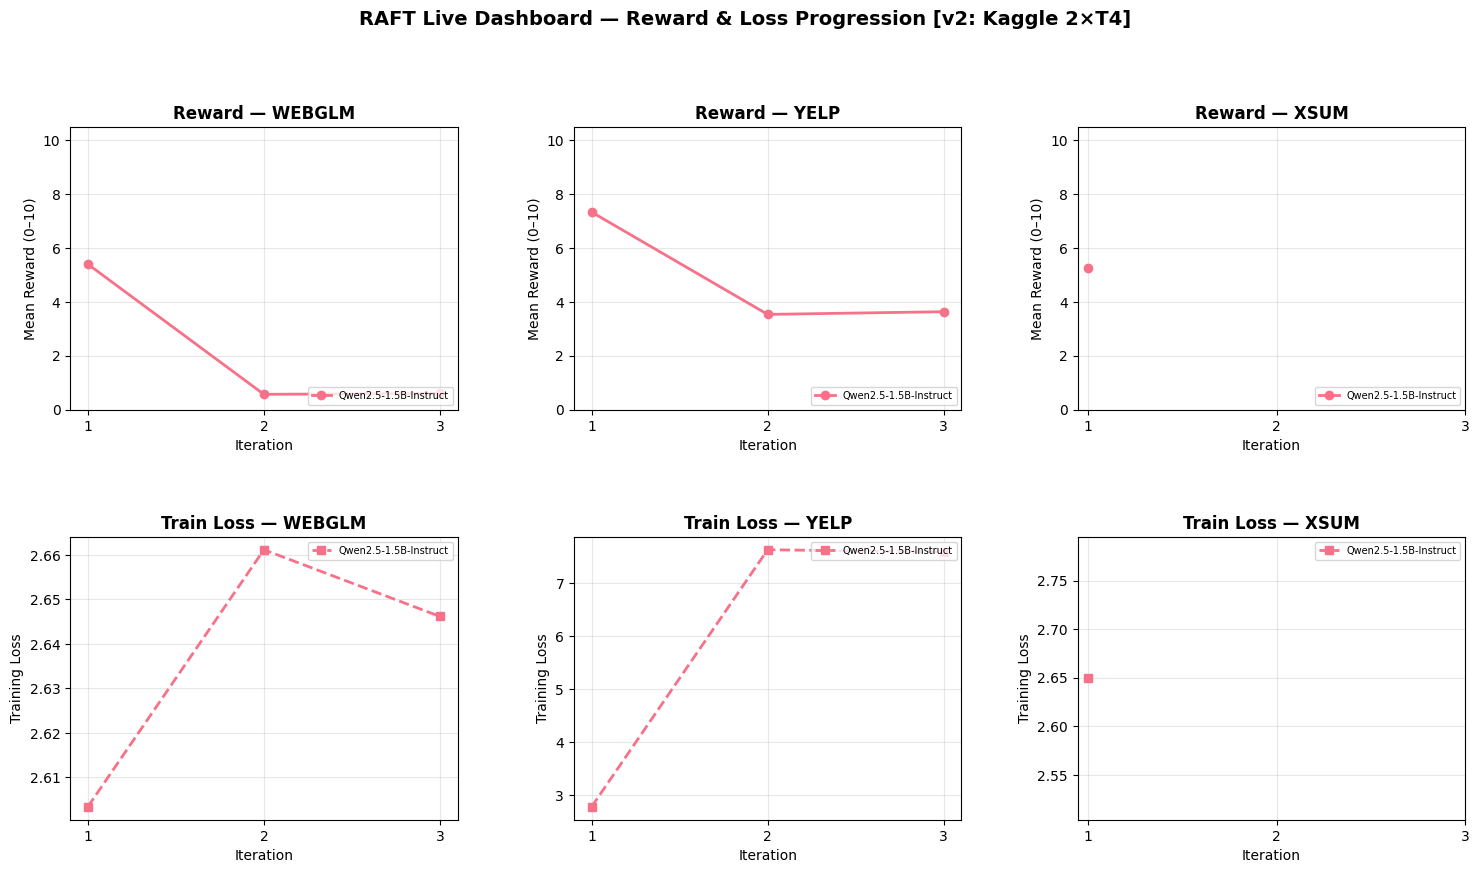

13:53:10 [INFO] IterativeRLHF —   [iter1 end] GPU 0: 1.6GB alloc / 3.8GB reserved / 15.6GB total
13:53:10 [INFO] IterativeRLHF —   [iter1 end] GPU 1: 2.1GB alloc / 2.1GB reserved / 15.6GB total
13:53:10 [INFO] IterativeRLHF —   [iter2 start] GPU 0: 1.6GB alloc / 3.8GB reserved / 15.6GB total
13:53:10 [INFO] IterativeRLHF —   [iter2 start] GPU 1: 2.1GB alloc / 2.1GB reserved / 15.6GB total
13:53:10 [INFO] IterativeRLHF — Stage 1: Sampling candidate responses…


📊 Chart saved → raft_outputs/raft_live_chart.png
  ✅  Done. Mean reward: 5.27/10 | Training loss: 2.6494

  🔄  Iteration 2/3 [Qwen2.5-1.5B-Instruct | xsum]


📝 [xsum] Sampling:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# CELL 8 — MAIN EXPERIMENT LOOP
# FIX #4: PolicyEngine reset per-dataset
# [v2] FIX #11: use_cache=True + reward._cache.clear() after each training step
# [v2] FIX #13: GPU memory logging per iteration
# ============================================================

def run_single_model_experiment(
    model_id: str,
    dataset_cache: Dict[str, Tuple[List[str], List[str]]],
    dataset_registry: List[Dict],
    config: Dict,
    tracker: EvaluationTracker,
    reward: HFRewardModel,
    plotter: LivePlotter,
) -> None:
    model_name = model_id.split("/")[-1]

    for ds_info in dataset_registry:
        ds_name = ds_info["name"]
        task    = ds_info["task"]
        prompts, contexts = dataset_cache[ds_name]

        print(f"\n{'━'*65}")
        print(f"  🤖 Model: {model_name}   📚 Dataset: {ds_name.upper()}")
        print(f"  🔁 Loading FRESH model (reset between datasets)")
        print(f"{'━'*65}")

        # FIX #4: re-instantiate for clean state
        policy = PolicyEngine(model_id)

        for iteration in range(1, config["iterations"] + 1):
            print(f"\n  🔄  Iteration {iteration}/{config['iterations']} "
                  f"[{model_name} | {ds_name}]")

            # [v2] FIX #13: log GPU memory at start of every iteration
            log_gpu_memory(f"iter{iteration} start")

            # ── Stage 1: Sample candidates ────────────────────────
            logger.info("Stage 1: Sampling candidate responses…")
            all_candidates: List[List[str]] = []
            for q, ctx in tqdm(
                zip(prompts, contexts),
                total=len(prompts),
                desc=f"📝 [{ds_name}] Sampling",
            ):
                candidates = policy.sample_responses(
                    q, ctx,
                    task=task,
                    num_samples=config["num_samples_per_prompt"],
                    max_new_tokens=config["max_new_tokens"],
                    temperature=config["temperature"],
                )
                all_candidates.append(candidates)

            # ── Stage 2: Score & select best-of-N ────────────────
            logger.info("Stage 2: Scoring with reward model…")
            best_responses, best_scores, all_scored = reward.select_best(
                prompts, contexts, all_candidates,
                task=task, verbose=True,
            )

            # ── Stage 3: Fine-tune ────────────────────────────────
            training_pairs = [
                {"prompt": q, "context": ctx, "response": r}
                for q, ctx, r in zip(prompts, contexts, best_responses)
            ]
            iter_output_dir = (
                config["output_root"]
                / model_name
                / ds_name
                / f"iter_{iteration}"
            )
            logger.info("Stage 3: LoRA fine-tuning…")
            updated_peft_model, training_loss = train_raft_step(
                policy, training_pairs, iter_output_dir, config, task=task
            )

            # ── FIX #11 + FIX #15: Sync model reference + re-enable use_cache ──
            # updated_peft_model is the freshly trained PeftModel from this iter.
            # We sync it back so iter N+1's get_base_model() unloads the right one.
            policy.model = updated_peft_model
            policy._base_model = updated_peft_model  # keep _base_model in sync too

            # Re-enable use_cache for generation (disabled during training)
            policy.model.config.use_cache = True
            try:
                policy.model.base_model.model.config.use_cache = True
            except AttributeError:
                pass
            logger.info("[v2] use_cache=True re-enabled on wrapper + base model.")

            # FIX #15: Force GPU 0 cache flush after model reference swap
            gc.collect()
            torch.cuda.empty_cache()
            torch.cuda.synchronize("cuda:0")
            logger.info(f"  [FIX #15] Post-swap GPU 0: "
                        f"{torch.cuda.memory_allocated(0)/1e9:.1f}GB alloc / "
                        f"{torch.cuda.memory_reserved(0)/1e9:.1f}GB reserved")

            # ── [v2] FIX #11: Clear stale reward scores ───────────
            reward._cache.clear()
            logger.info("[v2] Reward cache cleared.")

            # ── [v2] Sanity check: confirm generation still works ─
            sanity_out = policy.generate(
                prompts[0], contexts[0], task=task, max_new_tokens=30
            )
            logger.info(f"Post-train sanity [{iteration}]: '{sanity_out[:80]}'")
            if len(sanity_out.strip()) < 5:
                logger.error(
                    f"⚠️  SANITY FAILED iter {iteration}: empty output! "
                    f"Response='{sanity_out!r}' — use_cache or OOM issue."
                )
            else:
                logger.info(f"✅ Sanity OK: '{sanity_out[:60]}…'")

            # ── Stage 4: Log + store detail JSON ─────────────────
            tracker.log(
                model_name=model_name,
                dataset_name=ds_name,
                iteration=iteration,
                scores=best_scores,
                training_loss=training_loss,
                prompts=prompts,
                contexts=contexts,
                all_scored=all_scored,
                best_responses=best_responses,
            )

            # ── Stage 5: Redraw live dashboard ────────────────────
            plotter.push(
                model=model_name,
                dataset=ds_name,
                iteration=iteration,
                mean_score=float(np.mean(best_scores)),
                training_loss=training_loss,
            )
            plotter.redraw()

            print(
                f"  ✅  Done. Mean reward: {np.mean(best_scores):.2f}/10 "
                f"| Training loss: {training_loss:.4f}"
            )
            log_gpu_memory(f"iter{iteration} end")

        # Free GPU after all iterations for this dataset
        policy.free_memory()
        del policy
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


def run_full_experiment(
    policy_models: List[str],
    dataset_cache: Dict[str, Tuple[List[str], List[str]]],
    dataset_registry: List[Dict],
    config: Dict,
) -> EvaluationTracker:
    tracker = EvaluationTracker(config["output_root"])
    reward  = HFRewardModel()
    plotter = LivePlotter(
        datasets=[d["name"] for d in dataset_registry],
        models=[m.split("/")[-1] for m in policy_models],
        output_root=config["output_root"],
    )

    for model_id in policy_models:
        print(f"\n{'═'*65}")
        print(f"  🚀 Starting model: {model_id}")
        print(f"{'═'*65}")
        run_single_model_experiment(
            model_id=model_id,
            dataset_cache=dataset_cache,
            dataset_registry=dataset_registry,
            config=config,
            tracker=tracker,
            reward=reward,
            plotter=plotter,
        )

    print(tracker.summary())
    tracker.save()
    plotter.save_final()
    reward.free_memory()
    return tracker


# ── Run ────────────────────────────────────────────────────────
tracker = run_full_experiment(
    policy_models=POLICY_MODELS,
    dataset_cache=dataset_cache,
    dataset_registry=DATASET_REGISTRY,
    config=PROJECT_CONFIG,
)

---
## Cell 9 — Results Inspection & Stored File Explorer

In [ ]:
# ============================================================
# CELL 9 — RESULTS INSPECTION
# ============================================================

output_root = PROJECT_CONFIG["output_root"]
results_csv = output_root / "raft_results_all.csv"
details_dir = output_root / "iteration_details"

# ── Summary table ────────────────────────────────────────────
if results_csv.exists():
    df = pd.read_csv(results_csv)
    print("📊 Full results table:")
    display(df)

    print("\n📈 Final-iteration mean reward by model × dataset:")
    final_iter = df[df["iteration"] == df["iteration"].max()]
    pivot = final_iter.pivot_table(
        index="model", columns="dataset", values="mean_score"
    )
    print(pivot.to_string())

    print("\n📊 Score bars (mean over all datasets, final iteration):")
    model_avg = final_iter.groupby("model")["mean_score"].mean()
    for model, score in model_avg.sort_values(ascending=False).items():
        bar   = "█" * int(score)
        label = model[:30]
        print(f"  {label:<32} {bar} {score:.2f}/10")
else:
    print("No results CSV found. Run Cell 8 first.")

# ── Iteration detail JSON files ───────────────────────────────
print("\n📁 Stored iteration detail files:")
if details_dir.exists():
    json_files = sorted(details_dir.glob("*.json"))
    if json_files:
        for jf in json_files:
            with open(jf) as f:
                d = json.load(f)
            s = d["summary"]
            n_prompts = len(d.get("per_prompt", []))
            print(
                f"  {jf.name:<58} "
                f"mean={s['mean_score']:.2f} "
                f"std={s['std_score']:.2f} "
                f"loss={s['training_loss']}  "
                f"({n_prompts} prompts)"
            )
    else:
        print("  (none yet)")
else:
    print("  (directory not found)")

# ── LoRA adapter checkpoints ──────────────────────────────────
print("\n🗂️  Saved LoRA adapter checkpoints:")
for p in sorted(output_root.glob("**/iter_*")):
    if p.is_dir():
        files = list(p.iterdir())
        rel   = p.relative_to(output_root)
        print(f"  {rel}/  ({len(files)} files)")

# ── Saved chart files ─────────────────────────────────────────
print("\n🖼️  Saved chart files:")
for png in sorted(output_root.glob("*.png")):
    size_kb = png.stat().st_size // 1024
    print(f"  {png.name}  ({size_kb} KB)")

---
## Cell 10 — Inspect a Specific Iteration in Detail

Load any saved JSON to see all candidate responses, their individual scores, reasons, and the winner for any model/dataset/iteration combination.

In [ ]:
# ============================================================
# CELL 10 — INSPECT SPECIFIC ITERATION DETAIL
# Change the three variables below to inspect any saved run.
# ============================================================

INSPECT_MODEL   = "Qwen2.5-1.5B-Instruct"   # model_name (not full HF id)
INSPECT_DATASET = "webglm"                    # webglm | yelp | xsum
INSPECT_ITER    = 1                           # 1, 2, or 3

json_path = (
    PROJECT_CONFIG["output_root"]
    / "iteration_details"
    / f"{INSPECT_MODEL}__{INSPECT_DATASET}__iter{INSPECT_ITER}.json"
)

if json_path.exists():
    with open(json_path, encoding="utf-8") as f:
        detail = json.load(f)

    s = detail["summary"]
    print(f"\n{'═'*65}")
    print(f"  {INSPECT_MODEL} | {INSPECT_DATASET.upper()} | Iteration {INSPECT_ITER}")
    print(
        f"  mean={s['mean_score']}  std={s['std_score']}  "
        f"min={s['min_score']}  max={s['max_score']}  "
        f"loss={s['training_loss']}  ts={s['timestamp']}"
    )
    print(f"{'═'*65}")

    for pp in detail["per_prompt"][:3]:   # show first 3 prompts
        print(f"\n▶ Prompt {pp['prompt_idx']}: {pp['prompt'][:100]}…")
        print(f"  Context  : {pp['context'][:100]}…")
        print(f"  Candidates ({len(pp['candidates'])} total):")
        for c in pp["candidates"]:
            marker = " ⭐" if c["score"] == pp["best_score"] else "   "
            print(f"  {marker} [{c['score']:4.1f}] {c['response'][:80]}…")
            print(f"           Reason: {c['reason'][:80]}")
        print(f"  → Winner  [{pp['best_score']:.1f}]: {pp['best_response'][:100]}…")
else:
    print(f"File not found: {json_path.name}")
    print("\nAvailable detail files:")
    details_dir = PROJECT_CONFIG["output_root"] / "iteration_details"
    for jf in sorted(details_dir.glob("*.json")):
        print(f"  {jf.name}")

In [ ]:
!zip -r raft_outputs.zip /kaggle/working/raft_outputs/
from IPython.display import FileLink
FileLink(r'raft_output.zip')